In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
file_path ="/content/Marketing.xlsx"

df = pd.read_excel(file_path)

print("Data Loaded Successfully!")
df.head()


Data Loaded Successfully!


,id,c_date,campaign_name,category,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue
0,1,2021-02-01,facebook_tier1,social,349043,148263,7307.37,1210,13,1,4981
1,2,2021-02-01,facebOOK_tier2,social,348934,220688,16300.20,1640,48,3,14962
2,3,2021-02-01,google_hot,search,89459845,22850,5221.60,457,9,1,7981
3,4,2021-02-01,google_wide,search,127823,147038,6037.00,1196,24,1,2114
4,5,2021-02-01,youtube_blogger,influencer,10934,225800,29962.20,2258,49,10,84490


In [3]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             308 non-null    int64         
 1   c_date         308 non-null    datetime64[ns]
 2   campaign_name  308 non-null    object        
 3   category       308 non-null    object        
 4   campaign_id    308 non-null    int64         
 5   impressions    308 non-null    int64         
 6   mark_spent     308 non-null    float64       
 7   clicks         308 non-null    int64         
 8   leads          308 non-null    int64         
 9   orders         308 non-null    int64         
 10  revenue        308 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(7), object(2)
memory usage: 26.6+ KB


In [4]:
df.describe()


,id,c_date,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue
count,308.000000,308,3.080000e+02,3.080000e+02,308.000000,308.000000,308.000000,308.000000,3.080000e+02
mean,154.500000,2021-02-14 12:00:00,9.605628e+06,5.122475e+06,99321.038377,9739.996753,212.918831,26.113636,1.392512e+05
min,1.000000,2021-02-01 00:00:00,1.093400e+04,6.670000e+02,169.750000,20.000000,0.000000,0.000000,0.000000e+00
25%,77.750000,2021-02-07 18:00:00,1.278230e+05,1.479568e+05,9465.195000,1347.250000,20.750000,3.000000,8.580000e+03
50%,154.500000,2021-02-14 12:00:00,3.747540e+05,6.028100e+05,36765.150000,4349.500000,84.000000,9.000000,3.891700e+04
75%,231.250000,2021-02-21 06:00:00,4.387490e+06,3.254450e+06,129372.250000,13499.250000,270.500000,29.250000,1.370492e+05
max,308.000000,2021-02-28 00:00:00,8.945984e+07,4.199700e+08,880357.000000,61195.000000,1678.000000,369.000000,2.812520e+06
std,89.056162,NaN,2.543040e+07,2.631134e+07,144008.011181,12157.476244,300.459978,42.741288,2.763031e+05


In [5]:
df.head()

,id,c_date,campaign_name,category,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue
0,1,2021-02-01,facebook_tier1,social,349043,148263,7307.37,1210,13,1,4981
1,2,2021-02-01,facebOOK_tier2,social,348934,220688,16300.20,1640,48,3,14962
2,3,2021-02-01,google_hot,search,89459845,22850,5221.60,457,9,1,7981
3,4,2021-02-01,google_wide,search,127823,147038,6037.00,1196,24,1,2114
4,5,2021-02-01,youtube_blogger,influencer,10934,225800,29962.20,2258,49,10,84490


In [6]:
df = df.drop_duplicates()

df['c_date'] = pd.to_datetime(df['c_date'], errors='coerce')

num_cols = ['impressions','mark_spent','clicks','leads','orders','revenue']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

print("Data Cleaned")

Data Cleaned


In [7]:
df['CTR'] = df['clicks'] / df['impressions']
df['Click_to_Lead'] = df['leads'] / df['clicks']
df['Lead_to_Order'] = df['orders'] / df['leads']
df['ROI'] = df['revenue'] / df['mark_spent']

df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)


In [8]:
channel = df.groupby('category').agg({
    'impressions':'sum',
    'clicks':'sum',
    'leads':'sum',
    'orders':'sum',
    'mark_spent':'sum',
    'revenue':'sum'
}).reset_index()

channel['ROI'] = channel['revenue'] / channel['mark_spent']

channel

,category,impressions,clicks,leads,orders,mark_spent,revenue,ROI
0,influencer,77800724,749973,16939,3014,8305304.08,21119887,2.542940
1,media,1068337427,420003,10149,1566,5026674.76,6152960,1.224062
2,search,72298252,330054,7107,828,3460400.07,3705065,1.070704
3,social,359285996,1499889,31384,2635,13798500.91,11911454,0.863243


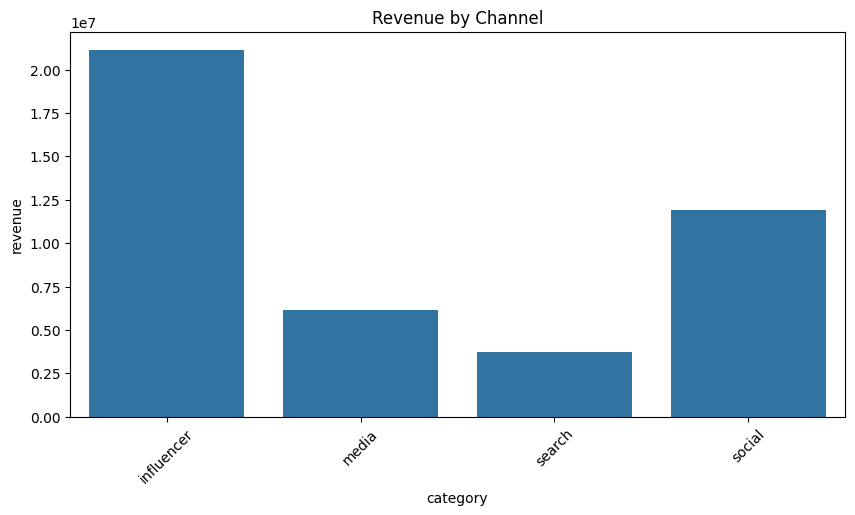

In [9]:
plt.figure(figsize=(10,5))
sns.barplot(data=channel, x='category', y='revenue')
plt.xticks(rotation=45)
plt.title("Revenue by Channel")
plt.show()

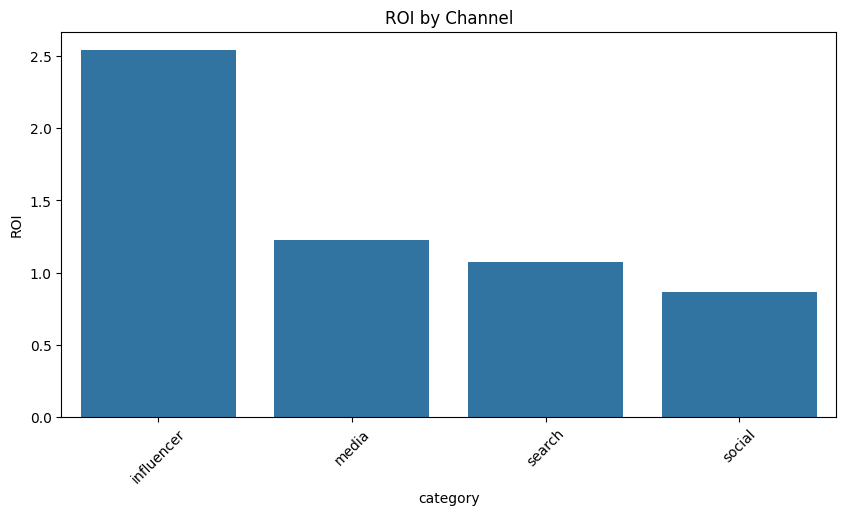

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(data=channel, x='category', y='ROI')
plt.xticks(rotation=45)
plt.title("ROI by Channel")
plt.show()


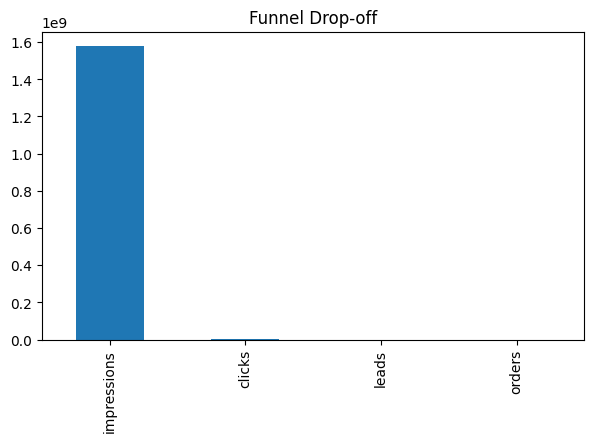

In [11]:
funnel = df[['impressions','clicks','leads','orders']].sum()

funnel.plot(kind='bar', figsize=(7,4), title="Funnel Drop-off")
plt.show()

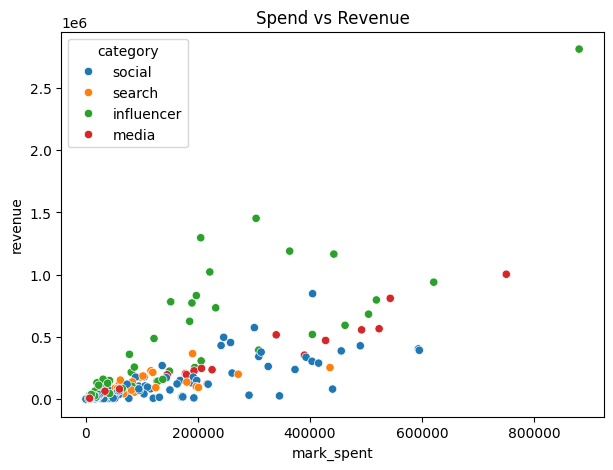

In [12]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='mark_spent', y='revenue', hue='category')
plt.title("Spend vs Revenue")
plt.show()

In [13]:
best = channel.sort_values('ROI', ascending=False).iloc[0]['category']
worst = channel.sort_values('ROI').iloc[0]['category']

print(" Best Channel:", best)
print(" Worst Channel:", worst)

print("\nInsights:")
print("- High ROI channels deserve more budget")
print("- Low ROI channels should be optimized or reduced")
print("- Improve funnel conversion at click-to-lead stage")


 Best Channel: influencer
 Worst Channel: social

Insights:
- High ROI channels deserve more budget
- Low ROI channels should be optimized or reduced
- Improve funnel conversion at click-to-lead stage
